# Figure 1 — Olfactory receptors as a clade, and when their two classes arose

Two questions, asked twice each — once from the tree, once from the protein language model.

1. Are olfactory receptors a coherent group inside the class A GPCRs? *(**a**, **b**)*
2. When did class I and class II split? *(**c**, **d**)*

The answer to the second is the one the rest of the paper is built on: the split is
subtended by gnathostome sequences only, so it dates to the jawed-vertebrate ancestor.

The trees are drawn in **iTOL**, a web service, so those panels are committed as SVG rather
than rebuilt by this notebook. The alignments and tree files they are drawn from are all in
`../data/`, and the commands that produced them are at the bottom of this notebook.
The embedding maps *are* rebuilt here.

In [1]:
import warnings
warnings.filterwarnings("ignore")   # library deprecation notices only; keeps stored output clean
import os, sys
os.environ.setdefault("TF_CPP_MIN_LOG_LEVEL", "3")

from pathlib import Path
import numpy as np, pandas as pd
import matplotlib.pyplot as plt

DATA    = Path("../data")
AP      = DATA / "GPCR_classA/AP"
REF     = DATA / "ReferenceTree"
FIGURES = Path("../figures")
EMB     = Path("../../Model_Inputs/Embeddings/proteins")

plt.rcParams.update({"figure.dpi": 130, "font.size": 8, "axes.titlesize": 9})
print("class A embeddings :", EMB / "gpcr_esmc_300m_embeddings")
print("six-species        :", EMB / "reference_tree_esmc_300m_embeddings")

class A embeddings : ../../Model_Inputs/Embeddings/proteins/gpcr_esmc_300m_embeddings
six-species        : ../../Model_Inputs/Embeddings/proteins/reference_tree_esmc_300m_embeddings


## a — The class A GPCR tree

722 human class A GPCRs: every protein in the reference proteome carrying the Pfam PF00001
domain above the gathering threshold. Four tip sets are read off the tree and used to colour
both this panel and **b**.

In [2]:
def accessions(path):
    """seqid files hold '9606.<uniprot>' per line."""
    return {l.strip().split(".", 1)[1] for l in open(path) if l.strip()}

stem   = "PF00001.9606.clustalo.gt01.lg.fasttree"
class1 = accessions(AP / f"{stem}.classI_seqids.txt")
class2 = accessions(AP / f"{stem}.classII_seqids.txt")
neuro  = accessions(AP / f"{stem}.NT_seqids.txt")
total  = sum(1 for l in open(AP / "PF00001.9606.fa") if l.startswith(">"))

print(f"  olfactory class I           {len(class1):>4}")
print(f"  olfactory class II          {len(class2):>4}")
print(f"  neurotransmitter receptors  {len(neuro):>4}")
print(f"  remaining class A           {total - len(class1) - len(class2) - len(neuro):>4}")
print(f"  {'-'*32}")
print(f"  total tips                  {total:>4}")
print()
assert not (class1 & class2) and not (class1 & neuro) and not (class2 & neuro), "tip sets overlap"
print("tip sets are disjoint.")

  olfactory class I             62
  olfactory class II           372
  neurotransmitter receptors    42
  remaining class A            246
  --------------------------------
  total tips                   722

tip sets are disjoint.


The olfactory receptors come out monophyletic, and the deepest split inside them is the
class I / class II divide.

*The drawing itself is made in iTOL from `../data/GPCR_classA/AP/PF00001.9606.clustalo.gt01.lg.fasttree`,
with `../data/GPCR_classA/uniprot_manager/*.itol_colors.txt` as the annotation.*

## b — The same 722 proteins as a language-model embedding

Each protein is one 960-d vector: the ESM-C 300M per-residue output, averaged over residues
with the BOS and EOS positions dropped. No tree is used here, so agreement with **a** is
independent evidence rather than a restatement of it.

In [3]:
def load_pooled(directory, drop_bos_eos):
    """One mean-pooled 960-d vector per protein, from the per-residue .npy arrays."""
    ids, X = [], []
    for fp in sorted(Path(directory).glob("*.npy")):
        emb = np.load(fp, mmap_mode="r")
        if drop_bos_eos:
            emb = emb[1:-1]
        ids.append(fp.stem)
        X.append(np.asarray(emb).mean(axis=0))
    return ids, np.vstack(X)

# The class A set strips BOS/EOS before pooling; the six-species set below does not.
# The two were embedded at different times and the difference is preserved here so that
# each map reproduces the published panel exactly.
gpcr_ids, Xg = load_pooled(EMB / "gpcr_esmc_300m_embeddings", drop_bos_eos=True)
gpcr = pd.DataFrame({"uniprot": [i.split(".", 1)[0] for i in gpcr_ids]})
gpcr["group"] = np.where(gpcr.uniprot.isin(neuro), "neurotransmitter",
                 np.where(gpcr.uniprot.isin(class1), "class 1",
                  np.where(gpcr.uniprot.isin(class2), "class 2", "the rest")))
print("embeddings:", Xg.shape)
print(gpcr.group.value_counts().to_string())

embeddings: (722, 960)
group
class 2             372
the rest            246
class 1              62
neurotransmitter     42


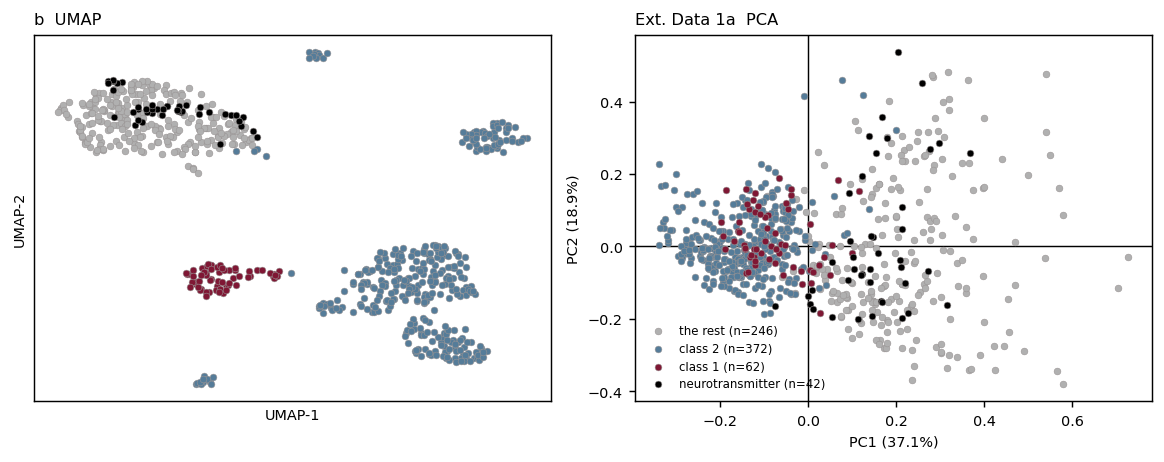

In [4]:
import umap
from sklearn.decomposition import PCA

PALETTE   = {"class 1": "#7f1734", "class 2": "#557c99",
             "neurotransmitter": "#000000", "the rest": "#B0B0B0"}
DRAW      = ["the rest", "class 2", "class 1", "neurotransmitter"]   # highlights on top

def draw(ax, coords, labels, palette, order, xlabel, ylabel, zero_axes=False):
    if zero_axes:
        ax.axhline(0, color="black", lw=0.8, zorder=0)
        ax.axvline(0, color="black", lw=0.8, zorder=0)
    for g in order:
        m = (labels == g).to_numpy()
        ax.scatter(coords[m, 0], coords[m, 1], s=14, color=palette[g],
                   edgecolors="#999494", linewidth=0.3, label=f"{g} (n={m.sum()})", zorder=2)
    ax.set_xlabel(xlabel); ax.set_ylabel(ylabel)

Zg = umap.UMAP(n_neighbors=50, min_dist=0.5, metric="cosine", random_state=42).fit_transform(Xg)
pg = PCA(n_components=2, random_state=42); Pg = pg.fit_transform(Xg)
evg = pg.explained_variance_ratio_ * 100

fig, (a, b) = plt.subplots(1, 2, figsize=(9, 3.6))
draw(a, Zg, gpcr.group, PALETTE, DRAW, "UMAP-1", "UMAP-2")
a.set_xticks([]); a.set_yticks([]); a.set_title("b  UMAP", loc="left")
draw(b, Pg, gpcr.group, PALETTE, DRAW, f"PC1 ({evg[0]:.1f}%)", f"PC2 ({evg[1]:.1f}%)", zero_axes=True)
b.set_title("Ext. Data 1a  PCA", loc="left")
b.legend(frameon=False, fontsize=6.5, loc="best")
fig.tight_layout()

Neurotransmitter and other class A receptors take one region; class I forms a single compact
cluster; class II resolves into several clusters that correspond to named subfamilies.
The PCA on the right has no free parameters, so the separation is not a UMAP artefact.

## c — Six species, and the age of the class I / class II split

584 sequences carrying the olfactory-receptor domain PF13853, from human, zebrafish,
hagfish, cloudy catshark, bambooshark and lancelet.

In [5]:
species = {"9606": "Homo sapiens", "7955": "Danio rerio", "7764": "Eptatretus burgeri",
           "75743": "Scyliorhinus torazame", "137246": "Chiloscyllium punctatum",
           "7740": "Branchiostoma lanceolatum"}

headers = [l[1:].strip() for l in open(REF / "PF13853.9606_7955_7740_7764_75743_137246.fa")
           if l.startswith(">")]
counts = pd.Series([h.split(".", 1)[0] for h in headers]).value_counts()
for taxid, n in counts.items():
    print(f"  {species.get(taxid, taxid):<28} {n:>4}")
print(f"  {'-'*34}")
print(f"  {'total':<28} {counts.sum():>4}")

  Homo sapiens                  433
  Danio rerio                   103
  Eptatretus burgeri             43
  Scyliorhinus torazame           2
  Chiloscyllium punctatum         2
  Branchiostoma lanceolatum       1
  ----------------------------------
  total                         584


![Six-species olfactory receptor tree](../figures/PF13853.6sp.einsi.gt01.treefile.itol.svg)

The duplication separating the two classes is subtended by gnathostome sequences only —
zebrafish and cartilaginous-fish sequences appear on **both** sides of it. That is what
places the split at the jawed-vertebrate ancestor rather than later.

The lancelet outgroup rests on a single tip: only one *Branchiostoma lanceolatum* protein
carries PF13853 in UniProt, so the root position is not stable even though the class split is.

### Extended Data Fig. 1c — is the split an artefact of one alignment or one tree method?

The same topology recovered under four combinations of aligner and tree-inference method.
The class I / class II split survives all four; the outgroup position does not.

| MAFFT E-INS-i + IQ-TREE | Clustal Omega + IQ-TREE |
|---|---|
| ![](../figures/sixsp_einsi_iqtree.itol.svg) | ![](../figures/sixsp_clustalo_iqtree.itol.svg) |
| **MAFFT E-INS-i + FastTree** | **MAFFT + IQ-TREE** |
| ![](../figures/sixsp_einsi_fasttree.itol.svg) | ![](../figures/sixsp_mafft_iqtree.itol.svg) |

## d — The same 584 proteins as an embedding

In [6]:
TAXON = {"9606": "Human", "7955": "Zebrafish", "7740": "Amphioxus",
         "7764": "Hagfish", "75743": "Catshark", "137246": "Bambooshark"}

# NB: pooled over all tokens, BOS/EOS included -- the convention this set was embedded under.
ref_ids, Xr = load_pooled(EMB / "reference_tree_esmc_300m_embeddings", drop_bos_eos=False)
ref = pd.DataFrame({"taxid": [i.split(".", 1)[0] for i in ref_ids],
                    "uniprot": [i.split(".", 1)[1] for i in ref_ids]})

human_class = pd.read_csv(DATA / "HumanTree/human433_OR_classes.csv")
lookup = dict(zip(human_class.uniprot,
                  human_class.OR_class.map({"Class_I": "Human (class 1)",
                                            "Class_II": "Human (class 2)"})))
ref["group"] = [lookup.get(u, "Human (unclassified)") if t == "9606" else TAXON[t]
                for t, u in zip(ref.taxid, ref.uniprot)]
print("embeddings:", Xr.shape)
print(ref.group.value_counts().to_string())

embeddings: (584, 960)
group
Human (class 2)    371
Zebrafish          103
Human (class 1)     62
Hagfish             43
Bambooshark          2
Catshark             2
Amphioxus            1


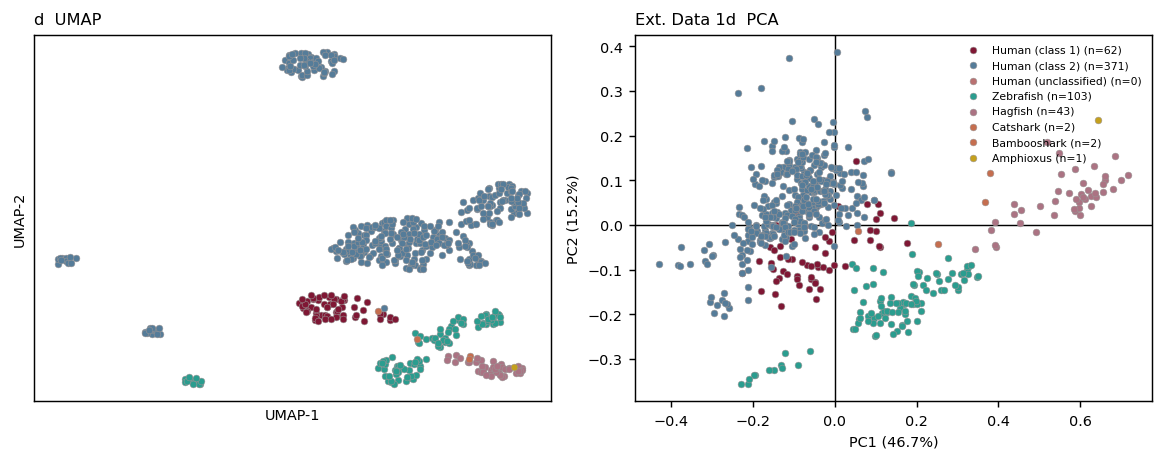

In [7]:
SPECIES_PALETTE = {"Human (class 1)": "#7f1734", "Human (class 2)": "#557c99",
                   "Human (unclassified)": "#b97171", "Zebrafish": "#2A9D8F",
                   "Amphioxus": "#C4A01D", "Hagfish": "#ab7383",
                   "Catshark": "#C56E4F", "Bambooshark": "#C56E4F"}
SPECIES_DRAW = ["Human (class 1)", "Human (class 2)", "Human (unclassified)",
                "Zebrafish", "Hagfish", "Catshark", "Bambooshark", "Amphioxus"]

Zr = umap.UMAP(n_neighbors=40, min_dist=0.7, metric="cosine", random_state=42).fit_transform(Xr)
pr = PCA(n_components=2, random_state=42); Pr = pr.fit_transform(Xr)
evr = pr.explained_variance_ratio_ * 100

fig, (a, b) = plt.subplots(1, 2, figsize=(9, 3.6))
draw(a, Zr, ref.group, SPECIES_PALETTE, SPECIES_DRAW, "UMAP-1", "UMAP-2")
a.set_xticks([]); a.set_yticks([]); a.set_title("d  UMAP", loc="left")
draw(b, Pr, ref.group, SPECIES_PALETTE, SPECIES_DRAW,
     f"PC1 ({evr[0]:.1f}%)", f"PC2 ({evr[1]:.1f}%)", zero_axes=True)
b.set_title("Ext. Data 1d  PCA", loc="left")
b.legend(frameon=False, fontsize=6, loc="best")
fig.tight_layout()

Human class II sequences form clusters with no non-human members — the terrestrial
radiation. The class I cluster contains a cartilaginous-fish sequence and sits beside the
zebrafish clusters, which is the embedding's version of the same result the tree gives.

The UMAP parameters differ between **b** (`n_neighbors=50, min_dist=0.5`) and **d**
(`n_neighbors=40, min_dist=0.7`); each panel is reproduced at the setting it was published
under. The PCA beside each one carries no such choice.

## How class I and class II were assigned

Not by gene name — by the tree. The human 433-receptor tree is rooted, the root's two
descendant clades are taken as the two classes, and the assignment is written out for every
downstream analysis to read.

In [8]:
from ete4 import PhyloTree

tree = PhyloTree(open(DATA / "HumanTree/human433_MFP_reorder.tree").read())
left, right = tree.children                       # the two clades descending from the root

assignment = pd.DataFrame(
    [{"leaf_id": leaf.name, "uniprot": leaf.name.split(".", 1)[-1], "OR_class": label}
     for clade, label in ((left, "Class_I"), (right, "Class_II"))
     for leaf in clade.leaves()]
).sort_values(["OR_class", "uniprot"], ignore_index=True)

print(assignment.OR_class.value_counts().to_string())

committed = pd.read_csv(DATA / "HumanTree/human433_OR_classes.csv")
same = assignment.set_index("uniprot").OR_class.sort_index().equals(
       committed.set_index("uniprot").OR_class.sort_index())
print(f"\nreproduces the committed human433_OR_classes.csv: {same}")

OR_class
Class_II    371
Class_I      62

reproduces the committed human433_OR_classes.csv: True


## How the trees were built

Recorded rather than run: each step needs an external tool, and the outputs are committed.

**Class A GPCRs (a)** — 722 sequences

```bash
hmmsearch --cut_ga PF00001.hmm uniprot_human_one_per_gene.fa   # Pfam PF00001, gathering threshold
clustalo -i PF00001.9606.fa -o PF00001.9606.clustalo_01.clustalo
trimal -gt 0.1 -in PF00001.9606.clustalo_01.clustalo -out ...clustalo.gt01
FastTree -lg ...clustalo.gt01 > PF00001.9606.clustalo.gt01.lg.fasttree
```

**Human olfactory receptors (used for class assignment, and for Fig. 3a)** — 433 sequences

```bash
einsi --thread 4 human_433_seqs.fa > human_433_seqs.einsi.fa
trimal -gt 0.01 -in human_433_seqs.einsi.fa -out human_433_seqs.einsi.gt01.fa
iqtree -s human_433_seqs.einsi.gt01.fa -st AA -mset LG -B 1000 -nt 8 -seed 42 \
       -pre human433_MFP
```

**Six species (c)** — 584 sequences, PF13853

```bash
einsi PF13853.9606_7955_7740_7764_75743_137246.fa > ...einsi.fa
trimal -gt 0.1 -in ...einsi.fa -out ...einsi.gt01
iqtree -s ...einsi.gt01 -st AA -B 1000 -seed 42
```

IQ-TREE 2 with ModelFinder and 1,000 ultrafast bootstrap replicates throughout.